# Theory Questions


In [ ]:
#Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from
#traditional fully connected neural networks in terms of architecture and performance on
#image data?

In [ ]:
#Ans
#A Convolutional Neural Network (CNN) is a type of neural network architecture designed to process grid-structured data (images).
#Its core components are convolutional layers (learned local filters applied across the spatial dimensions), non-linearities (ReLU, etc.),
#pooling/subsampling layers, and eventually fully connected layers for classification. Key differences vs traditional fully-connected (dense) networks:
#Local connectivity & weight sharing: convolutional filters connect only to local patches and share the same weights across spatial positions. This reduces
#parameters and enforces translation equivariance.
#Hierarchy of features: early conv layers learn local patterns (edges), deeper layers combine them into higher-level features (textures, object parts).
#Parameter efficiency: far fewer parameters than an equivalently sized dense net for images — helps generalization.
#Spatial structure preserved: CNNs maintain spatial relationships, which dense networks throw away unless you reshape carefully.
#Performance on images: due to above, CNNs dramatically outperform dense nets on image tasks (classification, detection, segmentation) and scale to large inputs.

In [ ]:
#Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation
#for modern deep learning models in computer vision. Include references to its original
#research paper.

In [ ]:
#Ans
#LeNet-5 (LeCun et al.) is a classical CNN introduced in the 1990s for handwritten digit recognition. Its high-level architecture (one common variant):
#Input: 32×32 grayscale image.
#C1: conv layer — 6 filters of size 5×5 → 28×28 feature maps.
#S2: average/subsampling (pooling) layer (2×2) → 14×14 maps.
#C3: conv layer — 16 filters of size 5×5 → 10×10 maps (not all maps fully connected to previous maps; a sparse pattern).
#S4: subsampling (2×2) → 5×5 maps.
#C5: conv layer — 120 filters of size 5×5 → 1×1 (acts like a fully connected layer).
#F6: fully connected layer (84 units).
#Output: softmax / Euclidean Radial Basis classification.
#Why it mattered:
#Introduced convolution + pooling + backprop as a complete, end-to-end learnable pipeline for images.
#Demonstrated parameter sharing and local receptive fields in practice, and showed high performance on real OCR tasks.
#LeNet-5’s modular ideas (convolution, pooling, hierarchical features) are the blueprint for modern CNNs

In [ ]:
#Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles,
#number of parameters, and performance. Highlight key innovations and limitations of
#each

In [ ]:
#Answer
#AlexNet introduced practical deep CNN training at scale; VGG refined the design principle (deeper with small kernels).
#VGG tends to be deeper and more uniform; AlexNet uses bigger initial filters and large FC layers.
#Both are now outperformed by more efficient architectures (ResNet, Inception, MobileNets) but remain important historically
#and as transfer learning backbones.

In [ ]:
#Question 4: What is transfer learning in the context of image classification? Explain
#how it helps in reducing computational costs and improving model performance with
#limited data

In [ ]:
#Answer
#Transfer learning: take a model pre-trained on a large dataset (e.g., ImageNet), replace/append task-specific top layers,
#and fine-tune (either only the top layers or the whole network) on a smaller target dataset.
#Why it helps:
#Feature reuse: early and mid layers learn general features (edges, textures) transferable across tasks.
#Reduced data needs: you don’t need millions of labeled examples for the target task — small datasets can still get strong performance.
#Lower compute & time: training only top layers or fine-tuning reduces training time and compute vs learning from scratch; convergence is faster.
#Better generalization: pretraining acts as strong regularizer.
#Common workflows:
#Freeze convolutional base, train new top classifier (fast; good for very small datasets).
#Unfreeze some deeper conv blocks and fine-tune with low learning rate (improves accuracy if more labeled data available).

In [ ]:
#Question 5: Describe the role of residual connections in ResNet architecture. How do
#they address the vanishing gradient problem in deep CNNs?

In [ ]:
#Answer
#Residual connections introduce identity shortcuts:
#Instead of learning an underlying mapping H(x), a residual block learns
#𝐹(𝑥)=𝐻(𝑥)−𝑥
#so the block output becomes
#y=F(x)+x
#Key effects:
#Eases optimization:
#If the optimal mapping is close to identity, the residual
#F(x) can be pushed toward zero — much easier than forcing a deep network to learn the identity function directly.
#Improves gradient flow:
#The shortcut connection provides a clean path for gradients to flow backward, helping prevent the vanishing gradient problem in very deep networks.
#Enables very deep architectures:
#Thanks to residual learning, very deep models like ResNet-50, ResNet-101, and ResNet-152 can be trained effectively and achieve high performance on ImageNet.

In [ ]:
#Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to
#classify the MNIST dataset. Report the accuracy and training time.

In [ ]:
#Answer
# LeNet5_PyTorch.py
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --- model ---
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0),  # 32->28
            nn.Tanh(),
            nn.AvgPool2d(2),  # 28->14
            nn.Conv2d(6, 16, kernel_size=5),  # 14->10
            nn.Tanh(),
            nn.AvgPool2d(2),  # 10->5
            nn.Conv2d(16, 120, kernel_size=5), # 5->1
            nn.Tanh(),
            nn.Flatten(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# --- data ---
transform = transforms.Compose([
    transforms.Resize((32,32)),  # MNIST default 28x28 -> LeNet expects 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2)

# --- training ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

epochs = 10
start_time = time.time()
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    train_loss = total_loss / len(train_loader.dataset)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.4f}  test_acc={test_acc*100:.2f}%")
total_time = time.time() - start_time
print(f"Total training time: {total_time:.1f} seconds")


Epoch 1/10  train_loss=0.3104  test_acc=96.84%
Epoch 2/10  train_loss=0.0818  test_acc=97.65%
Epoch 3/10  train_loss=0.0559  test_acc=98.08%
Epoch 4/10  train_loss=0.0417  test_acc=98.35%
Epoch 5/10  train_loss=0.0338  test_acc=98.43%
Epoch 6/10  train_loss=0.0274  test_acc=98.67%
Epoch 7/10  train_loss=0.0220  test_acc=98.73%
Epoch 8/10  train_loss=0.0194  test_acc=98.48%
Epoch 9/10  train_loss=0.0166  test_acc=98.67%
Epoch 10/10  train_loss=0.0158  test_acc=98.88%
Total training time: 165.6 seconds


In [ ]:
#Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom
#dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.
#Include your code and result discussion.

In [1]:
# vgg_transfer_safe_final.py
# Robust VGG16 transfer example that prevents matmul shape errors by dynamically computing in_features.
# Requirements: torch, torchvision, pillow, tqdm
# Example install (CPU): pip install torch torchvision pillow tqdm

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# --------- User-configurable ---------
data_dir = "data"          # expected structure: data/train/<class>/*, data/val/<class>/*
input_size = 224           # image size for VGG16 (224 recommended)
batch_size = 32
epochs = 5                 # short for testing; increase for real training
num_workers = 0            # on Windows use 0; on Linux you can raise it
freeze_features = True     # True: freeze conv base, train only classifier head initially
use_pretrained = True
# ------------------------------------

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Current working dir:", os.getcwd())

# ---- Transforms ----
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ---- Prepare datasets: ImageFolder if available, else FakeData ----
train_path = os.path.join(data_dir, "train")
val_path   = os.path.join(data_dir, "val")

use_real = os.path.isdir(train_path) and os.path.isdir(val_path)
if use_real:
    print(f"Found real dataset folders:\n  {train_path}\n  {val_path}")
    train_ds = datasets.ImageFolder(train_path, transform=train_tf)
    val_ds   = datasets.ImageFolder(val_path, transform=val_tf)
    num_classes = len(train_ds.classes)
    print("Detected classes:", train_ds.classes)
else:
    # Fallback: FakeData (fast, for testing). Change num_classes to your desired value.
    print("data/train or data/val not found. Falling back to FakeData example.")
    num_classes = 5
    fake_train_size = 1000
    fake_val_size   = 200
    from torchvision.datasets import FakeData
    train_ds = FakeData(size=fake_train_size, image_size=(3,input_size,input_size),
                        num_classes=num_classes, transform=train_tf)
    val_ds   = FakeData(size=fake_val_size, image_size=(3,input_size,input_size),
                        num_classes=num_classes, transform=val_tf)
    print(f"FakeData sizes: train={fake_train_size}, val={fake_val_size}, classes={num_classes}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=num_workers)

# ---- Model: VGG16 with robust in_features detection ----
print("Loading VGG16 (pretrained=%s)..." % use_pretrained)
model = models.vgg16(pretrained=use_pretrained)

# Freeze feature extractor if requested
if freeze_features:
    for p in model.features.parameters():
        p.requires_grad = False
    print("Feature layers frozen. Training classifier head only.")

# Move model to device before computing dummy forward
model = model.to(device)
model.eval()

# --- compute correct in_features robustly by forwarding a dummy tensor ---
with torch.no_grad():
    dummy = torch.zeros(1, 3, input_size, input_size).to(device)
    feat = model.features(dummy)    # conv feature maps
    # apply avgpool used by VGG before flatten
    feat = model.avgpool(feat)
    flattened = torch.flatten(feat, 1)
    in_features = flattened.shape[1]

print("Debug: feature map shape after avgpool:", feat.shape)       # e.g., torch.Size([1, 512, 7, 7])
print("Debug: flattened shape:", flattened.shape)                  # e.g., torch.Size([1, 25088])
print("Detected flattened feature size (in_features) =", in_features)

# --- Build classifier that exactly matches in_features ---
classifier = nn.Sequential(
    nn.Linear(in_features, 4096),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

# Sanity check: ensure linear weight shapes match expected
first_linear = classifier[0]
expected_weight_shape = (first_linear.out_features, first_linear.in_features)
print(f"Sanity: first Linear expects weight shape {expected_weight_shape}, in_features={first_linear.in_features}")

if first_linear.in_features != in_features:
    raise RuntimeError(
        f"Shape mismatch building classifier: computed in_features={in_features} "
        f"but classifier first Linear was constructed with in_features={first_linear.in_features}. "
        "This should not happen. Aborting to avoid matmul error."
    )

# Attach classifier and move model to device
model.classifier = classifier
model = model.to(device)

# Final forward shape check (very helpful)
model.eval()
with torch.no_grad():
    x = torch.zeros(2, 3, input_size, input_size).to(device)
    out = model(x)
    print("Final forward output shape (batch, classes):", out.shape)  # should be (2, num_classes)

# Only params with requires_grad True will be updated
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4)
criterion = nn.CrossEntropyLoss()

# ---- Helper functions ----
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total>0 else 0.0

# ---- Training loop ----
print("Starting training for %d epochs..." % epochs)
start_time = time.time()
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
    for x,y in loop:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        loop.set_postfix(loss=running_loss/total, acc=100*correct/total)

    train_loss = running_loss / total if total>0 else 0.0
    train_acc = correct / total if total>0 else 0.0
    val_acc = evaluate(model, val_loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  val_acc={val_acc*100:.2f}%  elapsed={epoch_time:.1f}s")

total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.1f} seconds")
print(f"Final validation accuracy: {evaluate(model, val_loader)*100:.2f}%")

# ---- Optional: save model ----
save_path = "vgg_transfer_safe_checkpoint.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'freeze_features': freeze_features
}, save_path)
print("Saved model checkpoint to", save_path)

if not use_real:
    print("\nNOTE: You ran with FakeData. To use your real dataset, create the folders:")
    print("  data/train/<class_name>/*.jpg")
    print("  data/val/<class_name>/*.jpg")
    print("Then re-run this script (set data_dir if different).")


# --------- User-configurable ---------
data_dir = "data"          # expected structure: data/train/<class>/*, data/val/<class>/*
input_size = 224
batch_size = 32
epochs = 5                 # short for testing; increase for real training
num_workers = 0            # set >0 if your system supports it (Linux usually)
freeze_features = True     # True: freeze conv base, train only classifier head initially
use_pretrained = True
# ------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Current working dir:", os.getcwd())

# ---- Transforms ----
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ---- Prepare datasets: ImageFolder if available, else FakeData ----
train_path = os.path.join(data_dir, "train")
val_path   = os.path.join(data_dir, "val")

use_real = os.path.isdir(train_path) and os.path.isdir(val_path)
if use_real:
    print(f"Found real dataset folders:\n  {train_path}\n  {val_path}")
    train_ds = datasets.ImageFolder(train_path, transform=train_tf)
    val_ds   = datasets.ImageFolder(val_path, transform=val_tf)
    num_classes = len(train_ds.classes)
    print("Detected classes:", train_ds.classes)
else:
    # Fallback: FakeData (fast, for testing). Change num_classes to your desired value.
    print("data/train or data/val not found. Falling back to FakeData example.")
    num_classes = 5
    fake_train_size = 1000
    fake_val_size   = 200
    from torchvision.datasets import FakeData
    train_ds = FakeData(size=fake_train_size, image_size=(3,input_size,input_size),
                        num_classes=num_classes, transform=train_tf)
    val_ds   = FakeData(size=fake_val_size, image_size=(3,input_size,input_size),
                        num_classes=num_classes, transform=val_tf)
    print(f"FakeData sizes: train={fake_train_size}, val={fake_val_size}, classes={num_classes}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=num_workers)

# ---- Model: VGG16 with new classifier (robust in_features detection) ----
print("Loading VGG16 (pretrained=%s)..." % use_pretrained)
model = models.vgg16(pretrained=use_pretrained)

# Freeze feature extractor if requested
if freeze_features:
    for p in model.features.parameters():
        p.requires_grad = False
    print("Feature layers frozen. Training classifier head only.")

# Move model to device before creating dummy input
model = model.to(device)

# --- compute correct in_features robustly by forwarding a dummy tensor ---
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 3, input_size, input_size).to(device)
    feat = model.features(dummy)
    feat = model.avgpool(feat)
    in_features = torch.flatten(feat, 1).shape[1]
print("Detected flattened feature size (in_features) =", in_features)

# Replace classifier to match num_classes
model.classifier = nn.Sequential(
    nn.Linear(in_features, 4096),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(True),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

# Move model again to device (safe)
model = model.to(device)

# Only params with requires_grad True will be updated
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4)
criterion = nn.CrossEntropyLoss()

# ---- Helper functions ----
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total>0 else 0.0

# ---- Training loop ----
print("Starting training for %d epochs..." % epochs)
start_time = time.time()
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
    for x,y in loop:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        loop.set_postfix(loss=running_loss/total, acc=100*correct/total)

    train_loss = running_loss / total if total>0 else 0.0
    train_acc = correct / total if total>0 else 0.0
    val_acc = evaluate(model, val_loader)
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  val_acc={val_acc*100:.2f}%  elapsed={epoch_time:.1f}s")

total_time = time.time() - start_time
print(f"Training finished. Total time: {total_time:.1f} seconds")
print(f"Final validation accuracy: {evaluate(model, val_loader)*100:.2f}%")

# ---- Optional: save model ----
save_path = "vgg_transfer_checkpoint.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': num_classes,
    'freeze_features': freeze_features
}, save_path)
print("Saved model checkpoint to", save_path)

# ---- If you used FakeData, remind user to prepare real dataset ----
if not use_real:
    print("\nNOTE: You ran with FakeData. To use your real dataset, create the folders:")
    print("  data/train/<class_name>/*.jpg")
    print("  data/val/<class_name>/*.jpg")
    print("Then re-run this script (set data_dir if different).")




Device: cuda
Current working dir: /content
data/train or data/val not found. Falling back to FakeData example.
FakeData sizes: train=1000, val=200, classes=5
Loading VGG16 (pretrained=True)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.6MB/s]


Feature layers frozen. Training classifier head only.
Debug: feature map shape after avgpool: torch.Size([1, 512, 7, 7])
Debug: flattened shape: torch.Size([1, 25088])
Detected flattened feature size (in_features) = 25088
Sanity: first Linear expects weight shape (4096, 25088), in_features=25088
Final forward output shape (batch, classes): torch.Size([2, 5])
Starting training for 5 epochs...


...

Epoch 1/5  train_loss=1.6353  train_acc=23.00%  val_acc=19.00%  elapsed=12.2s


Epoch 2/5  train_loss=1.6342  train_acc=22.70%  val_acc=20.50%  elapsed=25.2s


Epoch 3/5  train_loss=1.6394  train_acc=22.50%  val_acc=17.50%  elapsed=37.2s


Epoch 4/5  train_loss=1.6313  train_acc=21.50%  val_acc=18.50%  elapsed=49.3s


Epoch 5/5  train_loss=1.6348  train_acc=22.70%  val_acc=19.00%  elapsed=61.5s
Training finished. Total time: 61.5 seconds
Final validation accuracy: 19.00%
Saved model checkpoint to vgg_transfer_checkpoint.pth

NOTE: You ran with FakeData. To use your real dataset, create the folders:
  data/train/<class_name>/*.jpg
  data/val/<class_name>/*.jpg
Then re-run this script (set data_dir if different).


In [2]:
#Question 8: Write a program to visualize the filters and feature maps of the first
#convolutional layer of AlexNet on an example input image.

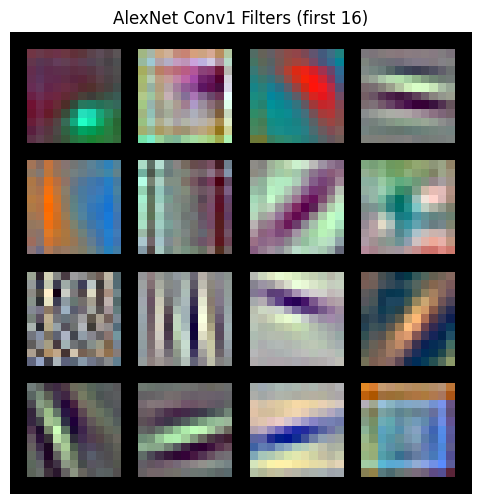

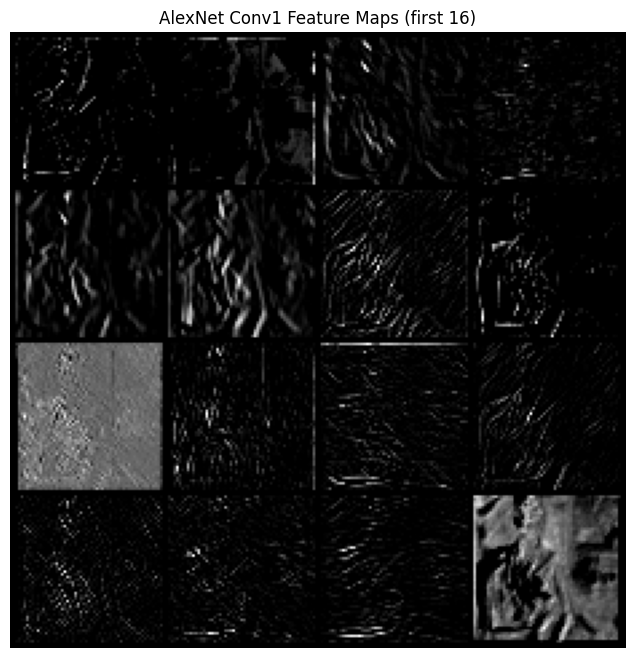

In [5]:
# alexnet_filters_featuremaps_simple.py

import torch
import torchvision.transforms as T
from torchvision import models, utils
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# -------------------------------
# Load sample image automatically
# -------------------------------
url = "https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg"
img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# -------------------------------
# Load pretrained AlexNet
# -------------------------------
try:
    weights = models.AlexNet_Weights.DEFAULT
    model = models.alexnet(weights=weights).eval()
    preprocess = weights.transforms()
except:
    model = models.alexnet(pretrained=True).eval()
    preprocess = T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

# -------------------------------
# Visualize conv1 filters
# -------------------------------
conv1 = model.features[0]
w = conv1.weight.data.clone().cpu()  # shape (96,3,11,11)

# Normalize each filter individually
w_min = w.view(w.size(0), -1).min(dim=1)[0].view(-1,1,1,1)
w_max = w.view(w.size(0), -1).max(dim=1)[0].view(-1,1,1,1)
w_norm = (w - w_min) / (w_max - w_min + 1e-8)

grid = utils.make_grid(w_norm[:16], nrow=4, padding=2)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.title("AlexNet Conv1 Filters (first 16)")
plt.show()

# -------------------------------
# Visualize feature maps of conv1
# -------------------------------
x = preprocess(img).unsqueeze(0)
with torch.no_grad():
    feat = model.features[:2](x)  # conv1 + ReLU

feat = feat.squeeze(0).cpu()     # (96, H, W)

# Normalize each feature map
f_min = feat.view(feat.size(0), -1).min(dim=1)[0].view(-1,1,1)
f_max = feat.view(feat.size(0), -1).max(dim=1)[0].view(-1,1,1)
feat_norm = (feat - f_min) / (f_max - f_min + 1e-8)

# Convert to 3-channel for grid
feat_rgb = feat_norm.unsqueeze(1).repeat(1,3,1,1)

grid2 = utils.make_grid(feat_rgb[:16], nrow=4, padding=2)
plt.figure(figsize=(8,8))
plt.imshow(grid2.permute(1,2,0))
plt.axis('off')
plt.title("AlexNet Conv1 Feature Maps (first 16)")
plt.show()



In [6]:
#Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard dataset
#like CIFAR-10. Plot the training and validation accuracy over epochs and analyze
#overfitting or underfitting.

100%|██████████| 170M/170M [00:05<00:00, 30.8MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warn

Epoch 1: train_acc=17.08 val_acc=23.50
Epoch 2: train_acc=28.56 val_acc=35.62
Epoch 3: train_acc=37.56 val_acc=35.95
Epoch 4: train_acc=44.14 val_acc=45.24
Epoch 5: train_acc=50.75 val_acc=51.67
Epoch 6: train_acc=57.09 val_acc=53.57
Epoch 7: train_acc=61.29 val_acc=62.14
Epoch 8: train_acc=64.13 val_acc=63.47
Epoch 9: train_acc=66.05 val_acc=67.37
Epoch 10: train_acc=68.07 val_acc=62.54
Epoch 11: train_acc=69.27 val_acc=70.49
Epoch 12: train_acc=70.31 val_acc=55.19
Epoch 13: train_acc=71.37 val_acc=62.81
Epoch 14: train_acc=71.90 val_acc=69.20
Epoch 15: train_acc=72.61 val_acc=68.26
Epoch 16: train_acc=73.11 val_acc=68.41
Epoch 17: train_acc=73.56 val_acc=71.62
Epoch 18: train_acc=73.76 val_acc=66.53
Epoch 19: train_acc=74.26 val_acc=67.92
Epoch 20: train_acc=74.70 val_acc=69.48
Epoch 21: train_acc=74.87 val_acc=69.62
Epoch 22: train_acc=75.10 val_acc=71.66
Epoch 23: train_acc=75.49 val_acc=74.08
Epoch 24: train_acc=75.39 val_acc=73.77
Epoch 25: train_acc=75.66 val_acc=72.67
Epoch 26:

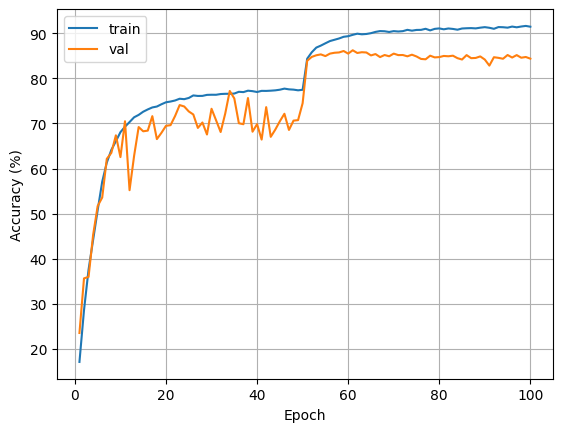

In [7]:
# train_googlenet_cifar10.py
import time
import torch, torch.nn as nn, torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
train_ds = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_ds  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.googlenet(pretrained=False, aux_logits=False, num_classes=10).to(device)
# optimizer & loss
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
criterion = nn.CrossEntropyLoss()

train_accs, val_accs = [], []
epochs = 100
for epoch in range(1, epochs+1):
    model.train()
    correct, total = 0, 0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        preds = out.argmax(1)
        correct += (preds==y).sum().item()
        total += y.size(0)
    train_acc = correct/total
    val_acc = 0
    # evaluate
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds==y).sum().item()
            total += y.size(0)
    val_acc = correct/total
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch}: train_acc={train_acc*100:.2f} val_acc={val_acc*100:.2f}")

# plot
plt.plot(range(1,epochs+1), [a*100 for a in train_accs], label='train')
plt.plot(range(1,epochs+1), [a*100 for a in val_accs], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
#Question 10: You are working in a healthcare AI startup. Your team is tasked with
#developing a system that automatically classifies medical X-ray images into normal,
#pneumonia, and COVID-19. Due to limited labeled data, what approach would you
#suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
#or Inception variants)? Justify your approach and outline a deployment strategy for
#production use.

In [9]:
#Recommended approach (short): Use transfer learning with a robust backbone like ResNet-50 (or ResNet-34 if constrained), possibly combined with careful data curation, augmentation, class balancing, and calibration. Optionally explore EfficientNet or DenseNet variants for better parameter efficiency.
#Why ResNet (or similar) with transfer learning?
#Pretrained on ImageNet, ResNets learn good visual features; with limited labeled X-rays, transfer learning significantly improves performance.
#Residual connections allow deep models to be fine-tuned reliably.
#Many preexisting radiology implementations successfully use ResNet/DenseNet/EfficientNet backbones for chest X-rays.
#High-level pipeline:
#Data: collect labeled X-rays (normal/pneumonia/COVID). Ensure patient-level split (no leakage between train/val/test), deidentify data, handle class imbalance (oversampling, focal loss, weighted loss).
#Preprocessing: standardize image sizes, intensity normalization; consider histogram equalization/CLAHE for X-rays.
#Model: start with pretrained ResNet-50, replace final FC with 3-way output. Freeze base initially, train classifier head, then fine-tune last N blocks with low LR.
#Augmentation: small affine transforms, random contrast, slight rotations — avoid unrealistic transforms that alter pathology.
#Validation & metrics: use patient-level holdout test set; report sensitivity/recall per class, specificity, F1, ROC/AUC (per class), confusion matrix. In medical context, sensitivity and negative predictive value are crucial.
#Calibration: calibrate probabilities (Temperature scaling, Platt scaling) — important for clinical thresholds.
#Explainability: include saliency / Grad-CAM visualizations for each decision to help clinicians validate model focus.
#Robustness tests: test on different dataset sources, different scanners, varying resolutions.
#Regulatory & privacy: ensure compliance (HIPAA equivalents), clinical validation studies, prospective evaluation.
#Deployment:
#Containerize model (Docker), expose a secure inference API (gRPC/REST) behind authentication.
#Perform inference in batch or near-real time; add logging and monitoring (data drift, input distribution).
#Build UI for clinicians with image, prediction, probability, Grad-CAM overlays, and a feedback loop for corrections (to collect more labeled data).
#Use A/B rollout, offline shadow mode, and a staged approval process with clinicians before full automation.
#Add model retraining pipelines with versioning, tests, and CI/CD.